In [2]:
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

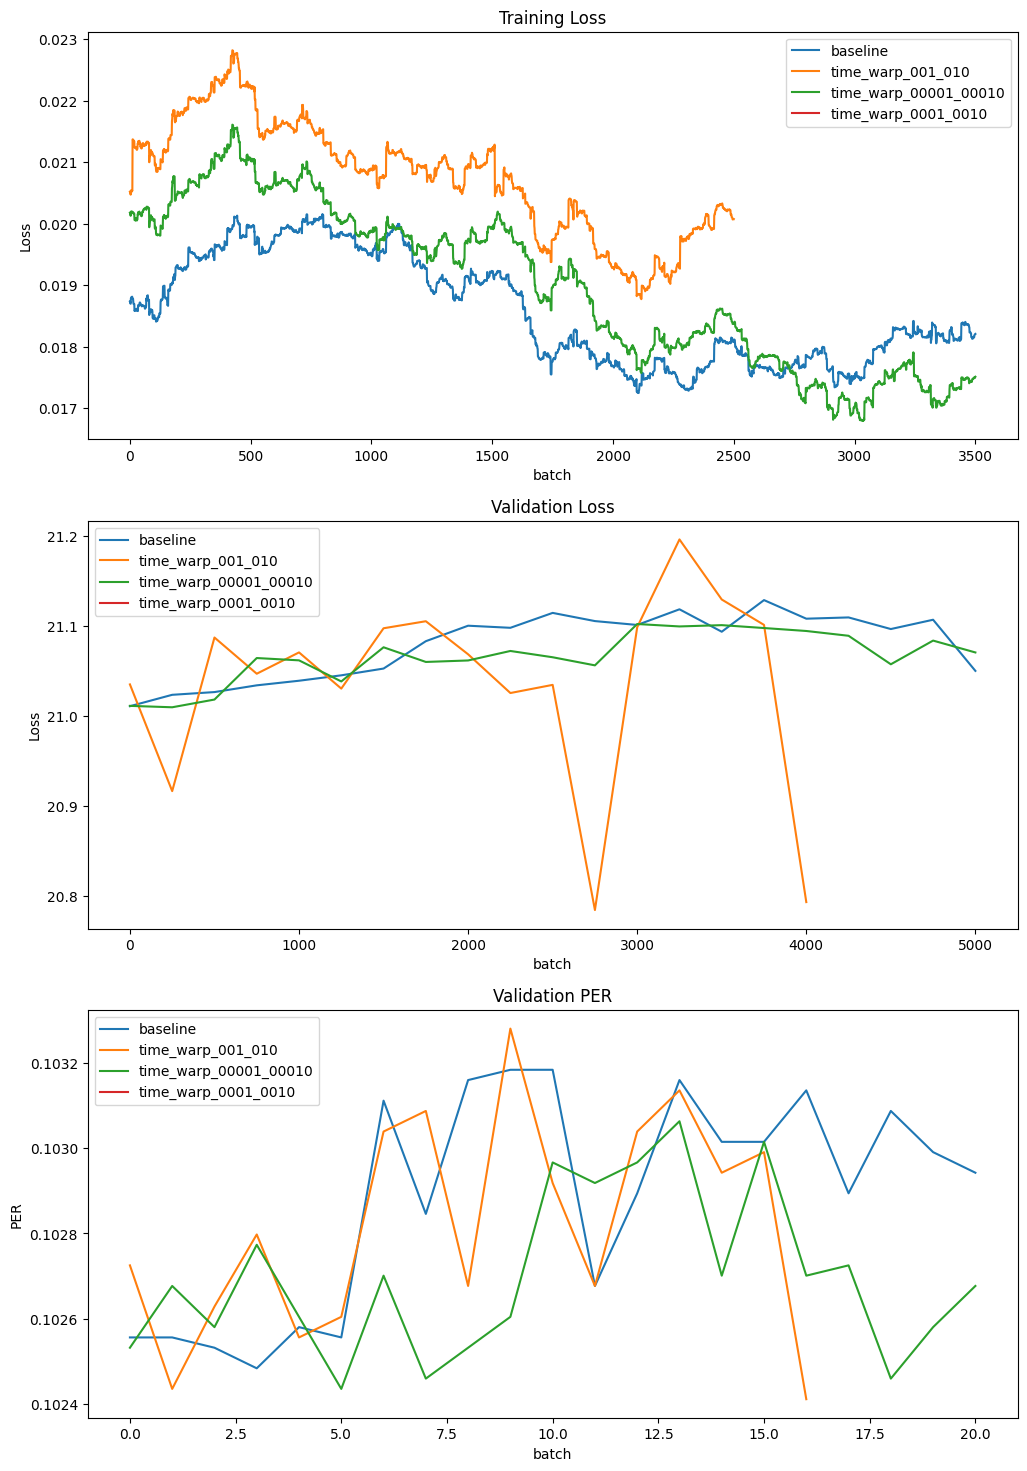

In [4]:
general_path = 'data/model_weights'
models = ['baseline','time_warp_001_010','time_warp_00001_00010','time_warp_0001_0010']

results = {}
for model in models:
    train_metrics = pd.read_csv(os.path.join(general_path, model, 'train_metrics.csv'), index_col=0)
    val_metrics = pd.read_csv(os.path.join(general_path, model, 'val_metrics.csv'), index_col=0)

    results[model] = {
        'train': train_metrics,
        'val': val_metrics
    }
# plot results
fig = plt.figure(figsize=(12, 18))
for model in models:
    train_metrics = results[model]['train']
    val_metrics = results[model]['val']

    plt.subplot(3, 1, 1)
    plt.plot(moving_average(train_metrics['train_losses'].tolist(),n=1500), label=model)
    plt.title('Training Loss')
    plt.xlabel('batch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(3, 1, 2)
    x = np.array(list(range(len(val_metrics['val_losses']))))*250
    plt.plot(x, val_metrics['val_losses'], label=model)
    plt.title('Validation Loss')
    plt.xlabel('batch')
    plt.ylabel('Loss')
    plt.legend()

    # val per
    plt.subplot(3, 1, 3)
    plt.plot(val_metrics['val_PERs'], label=model)
    plt.title('Validation PER')
    plt.xlabel('batch')
    plt.ylabel('PER')
    plt.legend()


In [5]:
df = pd.read_csv('/home/cgvallea/brainToText2025Challenge/data/model_weights/time_warp_001_010/rnn_test_predicted_sentences_checkpoint_batch_3999.csv')


# boxplot
df[['edit_distance', 'num_words']].groupby('num_words').mean().plot(kind='bar')



KeyError: "None of [Index(['edit_distance', 'num_words'], dtype='object')] are in the [columns]"